In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import tqdm
import seaborn as sns
import joblib
import itertools
import random
import copy

In [2]:
# Function to set random seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed) 
    np.random.seed(seed)
    random.seed(seed)

In [3]:
# Load all the numeric data
source = Path('../source/')
indpro = pd.read_excel(source / 'INDPRO.xlsx', sheet_name= 'Monthly')
unrate = pd.read_excel(source / 'UNRATE.xlsx', sheet_name= 'Monthly')
dff = pd.read_excel(source / 'FEDFUNDS.xlsx', sheet_name= 'Monthly')
cpi = pd.read_excel(source / 'CPIAUCSL.xlsx', sheet_name= 'Monthly')
epu = pd.read_excel(source / 'USEPUINDXD.xlsx', sheet_name= 'Monthly')
vix = pd.read_excel(source / 'VIXCLS.xlsx', sheet_name= 'Monthly')

# Join everything into a single df
data = indpro.merge(unrate, on = 'observation_date', how= 'outer')
data = data.merge(dff, on = 'observation_date', how = 'outer')
data = data.merge(cpi, on = 'observation_date', how = 'outer')
data = data.merge(epu, on = 'observation_date', how = 'outer')
data = data.merge(vix, on = 'observation_date', how = 'outer')

data.sort_values(by = 'observation_date', inplace= True)
data.columns = [col.lower() for col in data.columns] # Rename all columns to lowercase

del indpro, unrate, dff, cpi, epu, vix, source

# Stationarity

In [4]:
data['usepuindxd'] = (data['usepuindxd']/100) + 1 # EPU/100 + 1
apply_logs = ['cpiaucsl', 'indpro', 'vixcls', 'usepuindxd'] # Columns we'll apply logs to
log_cols = [f'log_{col}' for col in apply_logs] # Names of the log columns
data[log_cols] = np.log(data[apply_logs]) # Apply logs to the columns

# Compute log differences and plain differences
data["inflation"]    = 1200.0 * (data["log_cpiaucsl"] - data["log_cpiaucsl"].shift(1))
data["delta_indpro"] = 1200.0 * (data["log_indpro"]   - data["log_indpro"].shift(1))

del apply_logs, log_cols

We have numerical data spanning the 1990-2026 period

## Rough (visual) check on stationarity 

In [5]:
# Function to plot the time series data
def plot_series(columns: list, data: pd.DataFrame):
    n_vars = len(columns)
    fig, axes = plt.subplots(n_vars, 1, figsize=(10, 3*n_vars), sharex=False)
    for i, col in enumerate(columns):
        axes[i].plot(data[col])
        axes[i].set_title(col)
    plt.tight_layout()
    plt.show()

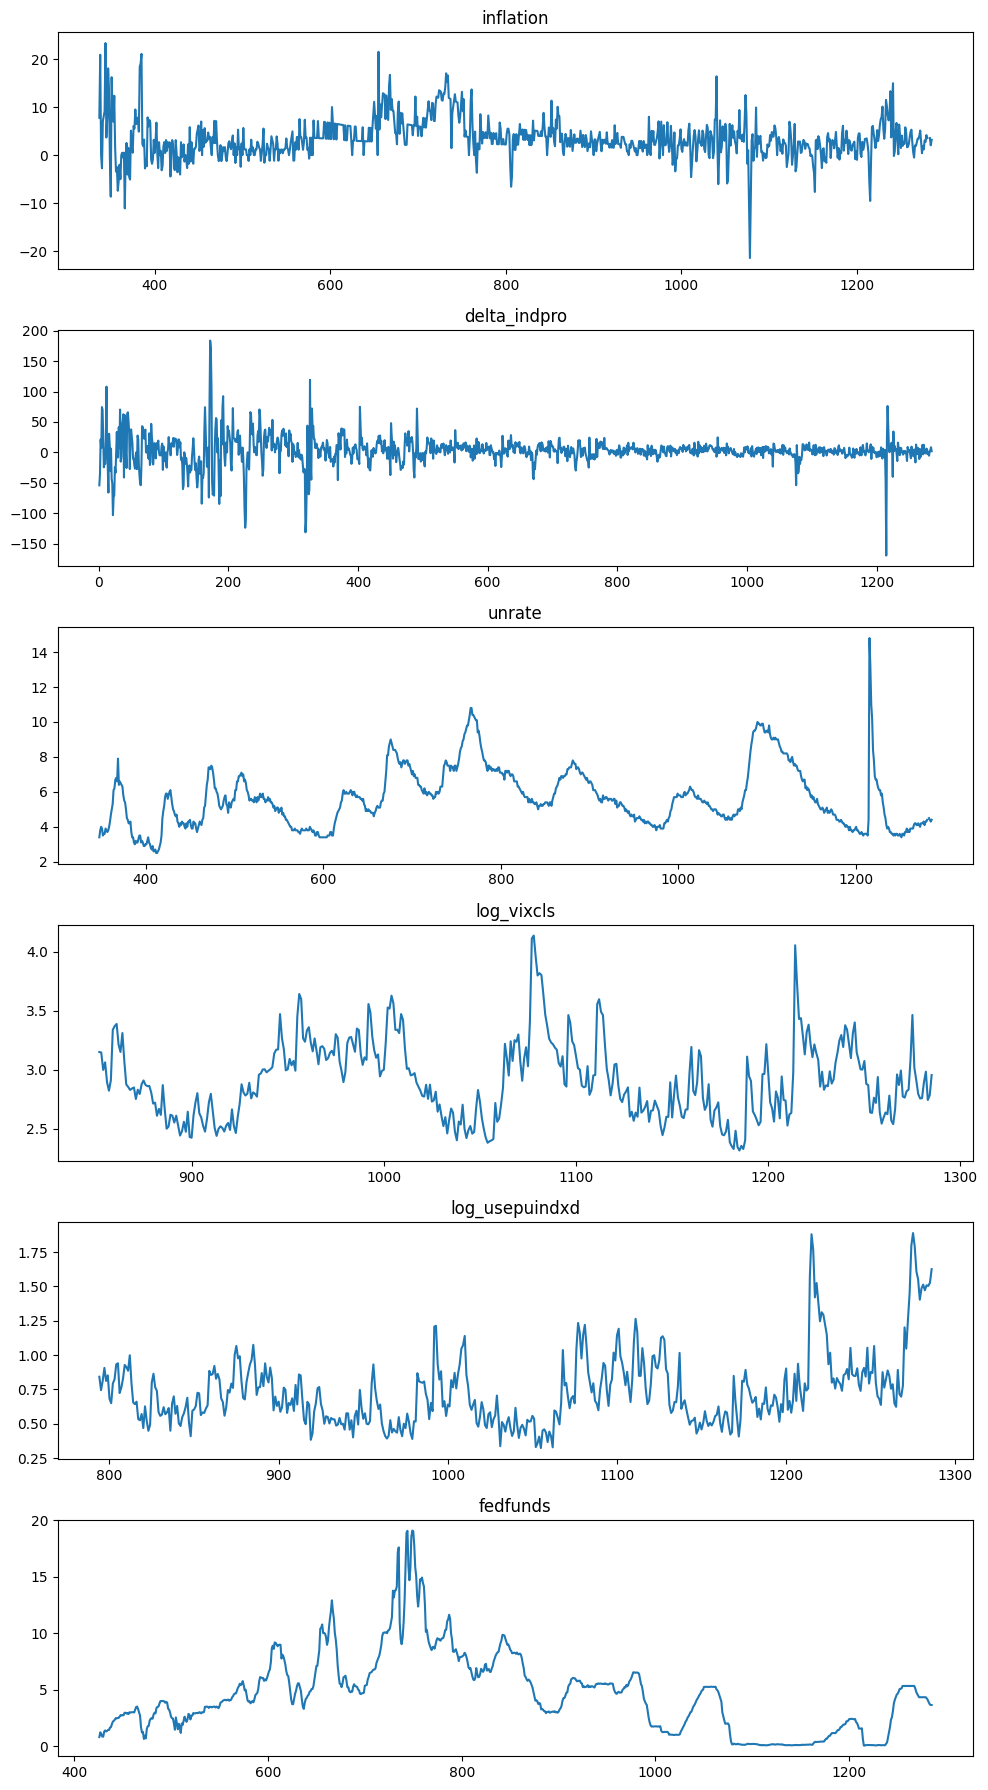

In [6]:
columns = ['inflation', 'delta_indpro', 'unrate', 'log_vixcls', 'log_usepuindxd', 'fedfunds'] 
plot_series(columns, data)

# VAR:

Instead of ARIMA, we think that the best analogue to a machine learning/deep learning model will be a VAR model, since it'll estimate every equation simultaneously and will consider interdependencies between variables

### Lag order:
To select the lag order, we'll be following standard practice and use information criterions 

### Estimation:
Since the VAR model was giving me matmul warnings whenever the lag order was higher than one, I decided to check myself where this error was coming from. At first I thought it was some perfect collinearity which made the $(Z'Z)$ matrix non invertible, but it turns out that the problem was coming from the $Z'Y$ multiplication. For some reason, the `@` multiplication was having issues with this two matrices, so instead I replaced them with the einsum matrix multiplication: 

$$Z'Y_{ij} = \sum_{t=1}^T Z_{ti} Y_{tj}$$

I also computed the betas to then compare them to the statsmodels VAR estimations and prove that even though we get matmul warnings, the coefficients are perfectly estimated. Of course the statsmodels estimations are preferred since they also have the computations for the standard errors, p-values, etc. But I just wanted to make sure that the $\hat{\beta}$ was correctly estimated and that we didn't have any perfect collinearity issues. To compute the betas, I use standard OLS:
$$
\hat{\beta} = \underbrace{(Z'Z)^{-1}}_{k \times k} \underbrace{Z'}_{k \times T} \underbrace{Y}_{T \times n}
$$
For VAR models, the $\hat{\beta}$ will be a matrix, with dimension $k\times n$, where $k = n\times lags + 1$ (if we estimate a model with intercept). This is equivalent to simultaneously estimating $n$ functions, one for each dependent variable, each with $k$ parameters, which correspond to each of the independent variables

All the exploratory analysis of whether the $\beta$ is correctly estimated is in the VAR_exploratory.ipynb notebook

# XGBoost:

In [7]:
# Class to prepare the data for the XGBoost model
class XGBoostData():
    def __init__(self, data: pd.DataFrame, forecast_horizon: int, lags: int, cut: int):
        self.data = data.copy()
        self.lags = lags
        self.forecast_horizon = forecast_horizon
        columns = list(self.data.columns)
        
        # Train-test split
        self.train_data = self.data.iloc[:cut, :]
        self.test_data = self.data.iloc[cut:, :]

        # Buffer to ensure we have enough data to create lags and targets in the test set
        buffer_len = lags + forecast_horizon - 1
        buffer = self.train_data.iloc[-buffer_len:, :]
        self.test_data = pd.concat([buffer, self.test_data])

        # Create the lagged features and targets for both train and test sets
        self.train_data, self.targets, _ = self.create_lags_targets(self.train_data, self.forecast_horizon, self.lags, columns)
        self.test_data, _, _ = self.create_lags_targets(self.test_data, self.forecast_horizon, self.lags, columns)

        # These are the features we'll use
        self.features = [col for col in self.train_data.columns if col not in self.targets]

        self.X_train = self.train_data[self.features]
        self.X_test = self.test_data[self.features]
        self.y_train = self.train_data[self.targets]
        self.y_test = self.test_data[self.targets]

    # This function creates the lagged features and targets for the XGBoost model
    def create_lags_targets(self, data, forecast_horizon: int, lags: int, col_list: list):
        data = data.copy()
        lagged_cols = []
        for lag in range(1, lags): 
            # We model y_{t+h} as a function of the current value y_t and its past lags.
            # Therefore, if lags = 3, the predictors are [y_t, y_{t-1}, y_{t-2}],
            # E.g: If lags = 3, then data already has y_t, so we need y_{t-1} and y_{t-2}. 
            # We want the range to be exclusive of the last lag, otherwise we'd be incorporating 4 lags
            for col in col_list:
                data[f'{col}_lag{lag}'] = data[col].shift(lag) # Shift by the lag amount
                lagged_cols.append(f'{col}_lag{lag}') # Save the column names just in case
        data = data.dropna().reset_index(drop = True) # The first observations will have NAs, so we drop them

        shift_nmbr = -forecast_horizon
        targets = []
        for col in col_list:
            data[f'f{forecast_horizon}_{col}'] = data[col].shift(shift_nmbr) # Now shift in the opposite direction to create targets
            targets.append(f'f{forecast_horizon}_{col}')
        data = data.dropna().reset_index(drop = True) # The last observations will have NAs, so we drop them
        return data, targets, lagged_cols
    

In [8]:
# This class will prepare the XGBoost model for multiple targets
class MultiOutputXGBGridSeach():
    def __init__(self, param_grid :dict , cv, n_jobs = 1, seed : int = 42, output_dir : str | None= None, forecast_horizon: int = 1):
        self.param_grid = param_grid
        self.cv = cv
        self.output_dir = output_dir if output_dir is not None else None
        self.forecast_horizon = forecast_horizon
        
        # XGBoost can only target one variable at a time
        self.xgb = XGBRegressor(objective='reg:squarederror', random_state = seed, n_jobs = 1) # We set it to minimize squared error
        model = MultiOutputRegressor(self.xgb) # This allows us to fit as many models as we need to target all the variables we want at the same time
        # Grid search for hyperparameter tuning
        self.search = GridSearchCV(
            estimator= model,
            param_grid= self.param_grid,
            cv= self.cv,
            scoring="neg_mean_squared_error",
            n_jobs=n_jobs
        )

    def fit(self, X, y):
        self.search.fit(X, y)
        self.best_estimator = self.search.best_estimator_
        self.best_params = self.search.best_params_
        self.best_score = self.search.best_score_

        if self.output_dir is not None:
            os.makedirs(self.output_dir, exist_ok= True)
            joblib.dump(self.search, os.path.join(self.output_dir, f'xgb_gridsearch_{self.forecast_horizon}.pkl'))
        return self.best_estimator, self.best_params
    
    def predict(self, X):
        return self.search.predict(X)

# LSTM:

## Time series through a LSTM:
If we're considering every state of the economy at time $t$ as the analogue to a "word" in NLP, then it's "embedding" will look something like this:

$$ e_t = (y_t, u_t, i_t, \pi_t, VIX_t, EPU_t) $$

Then for a given time $t=j$, we will have some path: $e_0, e_1, ..., e_j$, which we can consider the analogue to a "sentence"

## NAs:
In this setting, time series have inconsistent lenghts, so for a given time $t = j$, some variables may have NAs while others have actual values. NAs become an issue because we can't just pad the missing values, as it'd look something like this:

$$ e_j = (y_j, \text{<PAD>} , i_j, \pi_j, \text{<PAD>}, EPU_j) $$

In the traditional NLP setting, there is no case where an embedding might have missing values, but rather padding gets its own embedding. Thus, my opinion is that we must drop any observations that have at least one missing value.

# Practical aspects: 
In order to pass this numerical data as an input to the GRU/LSTM, we need some tensor with shape `(batch_size, max_len, n_features)`. In this case, `max_len` $= T$ will be the entire length of our training dataset and `n_features` will be the number of time series we have. Batching will be handled by the dataloader. Having $T$ as our max length is not the most efficient choice since most of our sequences will be very heavily padded (e.g.; the first sequence in our dataset will be mostly padding, except for the last "embedding" in the sequence), but it will give us some flexibility in order to endogenously select the "optimal" lag order through the attention mechanism. This is a strict improvement relative to the VAR and XGBoost models whose lag order has to be determined exogenpously.


In [9]:
class MacroVariablesDataset(Dataset):
    def __init__(self, input_data: pd.DataFrame, scaler_x, scaler_y, forecast_horizon: int, max_len: int, cut : int | None = None, train: bool = True):
        self.data = input_data.copy()
        self.scaler_x = scaler_x
        self.scaler_y = scaler_y
        self.forecast_horizon = forecast_horizon
        columns = list(self.data.columns)
        self.max_len = max_len

        if cut is None:
            cut = int(len(self.data) * 0.8)
        # For the training dataset, we'll fit the scaler and then for the test dataset, we'll use the already fitted scaler
        if train:
            self.data = self.data.iloc[:cut, :].copy() # For the training dataset, we just select the observations up to the cut
        else:
            assert cut > self.max_len + self.forecast_horizon, f"Not enough observations for the buffer: cut = {cut}, max_len = {self.max_len}" # Just in case
            buffer_start = cut - self.max_len - self.forecast_horizon # We need at least max_len + forecast_horizon observations for the buffer
            self.data = self.data.iloc[buffer_start:, :].copy() # This will be our test dataset, which will include the buffer

        # Create our y variables with the desired horizon and keep track ofs our target variables
        self.data, self.targets = self.create_target(self.data, self.forecast_horizon, columns)
        # These will be our features
        self.features = [col for col in self.data.columns if col not in self.targets]

        # We'll only fit the scaler on the training data and use the already fitted scaler for testing
        if train:
            X = self.scaler_x.fit_transform(self.data[self.features].astype(np.float32))
            y = self.scaler_y.fit_transform(self.data[self.targets].astype(np.float32))
        else:
            X = self.scaler_x.transform(self.data[self.features].astype(np.float32)) # Use already fitted scaler
            y = self.data[self.targets].to_numpy(np.float32) # y unscaled

        self.n_obs = X.shape[0]
        sequences = []
        lengths = []
        for i in range(self.n_obs):
            xt = X[:i+1, :] # For time t, select all observations from j = 0, ..., t]
            xt, L = self.pad_sequence(xt, dtype= torch.float) # Pad the sequence and get the length
            lengths.append(L) # Record every length
            sequences.append(xt) # Create an array of sequences

        self.X = torch.stack(sequences) # Create the X
        self.y = torch.tensor(y, dtype = torch.float)
        self.lengths = torch.tensor(lengths, dtype = torch.long)

        # During testing, we want to cut out the buffer observations
        if not train:
            self.X = self.X[max_len:]
            self.y = self.y[max_len:]
            self.lengths = self.lengths[max_len:]

    # This function creates the target variables
    def create_target(self, data: pd.DataFrame, forecast_horizon: int, col_list: list):
        data = data.copy()
        shift_nmbr = -forecast_horizon
        targets = []
        for col in col_list:
            data[f'f{forecast_horizon}_{col}'] = data[col].shift(shift_nmbr)
            targets.append(f'f{forecast_horizon}_{col}')
        data = data.dropna().reset_index(drop=True) # For now I'll just drop all NAs
        return data, targets
    
    # This will pad the training sequences with zeros if they are shorter than max_len and also truncate them if they are longer
    def pad_sequence(self, sequence, dtype):
        nrows, ncols = sequence.shape
        if nrows < self.max_len: # If shorter
            seq = torch.cat([torch.tensor(sequence, dtype= dtype), torch.zeros(self.max_len - nrows, ncols, dtype = dtype)]) # concatenate with zeros
            seq = seq[-self.max_len:, :] 
            return seq, nrows
        else:
            seq = torch.tensor(sequence, dtype= dtype)
            trunc_seq = seq[-self.max_len:, :] # Truncate if longer
            return trunc_seq, self.max_len
    
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


In [10]:
# This class will set up our LSTM architecture
class LSTMForecasting(nn.Module):
    def __init__(self, input_cols: list, target_cols: list, hidden_size: int, num_layers: int, p_dropout: float, bidirectional : bool = False):
        super(LSTMForecasting, self).__init__()
        self.input_cols = list(input_cols)
        input_size = len(self.input_cols)
        self.targets = list(target_cols)
        self.n_outputs = len(self.targets)
        # self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first= True, dropout= p_dropout, bidirectional= bidirectional)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first= True, dropout= p_dropout, bidirectional= bidirectional)

        self.fc = nn.Linear((2 * hidden_size), self.n_outputs) if bidirectional else nn.Linear((hidden_size), self.n_outputs)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(p_dropout),
            self.fc,
        )
        self.attention = nn.Linear(2 * hidden_size, 1) if bidirectional else nn.Linear(hidden_size, 1)
    
    def forward(self, xnum, lengths):
        _, T, _ = xnum.shape
        packed = pack_padded_sequence(xnum, lengths.cpu(), batch_first= True, enforce_sorted= False) # This is so that the GRU doesn't process all the padding
        #out, _ = self.gru(packed) # Pass throught the GRU
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=T) # Add the padding back
        device = out.device
        mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.to(device).unsqueeze(1)) # This is 1 if there's a real value and 0 if there's padding
        scores = self.attention(out).squeeze(-1) # Pass through the attention block
        scores = scores.masked_fill(~mask, -1e9) # Set all the padding scores to essentially zero
        weights = torch.softmax(scores, dim=1) # Compute scores
        context = torch.sum(out * weights.unsqueeze(-1), dim=1) # Weighted average of the GRU output
        x = self.head(context) # Linear layer for regression
        return x, weights


In [11]:
def train_model(model, dataset, device, batch_size = 64, num_epochs = 100, lr = 3e-4, l2 = 0.0, qui = False, seed = 42, val_dataset = None, patience = 5):
    set_seed(seed)
    model.to(device)
    criterion = nn.MSELoss() 
    dataloader = DataLoader(dataset, batch_size= batch_size, shuffle = True) # Create a dataloader from the dataset to iterate over it in batches
    val_loader = DataLoader(val_dataset, batch_size= batch_size, shuffle= False) if val_dataset is not None else [] # Validation dataloader if we're using validation set
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay= l2) # Adam optimizer

    scaler_y = dataset.scaler_y
    avg_loss = None
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    best_epoch = num_epochs
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0 # To keep track of the average loss for each epoch
        for xnum, y, lengths in dataloader:
            xnum, y = xnum.to(device), y.to(device).float()
            optimizer.zero_grad() # Re initialize gradients on each iteration
            output, _ = model(xnum, lengths) # Forward pass
            loss = criterion(output, y) # Compute loss

            loss.backward() # Compute gradients
            optimizer.step() # Update weights
            running_loss += loss.item()

        avg_loss = running_loss/len(dataloader) # Compute average loss for each epoch
    
        if val_dataset is not None:
            model.eval() # Evaluation mode
            val_loss = 0.0
            with torch.no_grad(): # We don't need gradients for validation
                for xnum, y, lengths in val_loader:
                    xnum, y = xnum.to(device), y.to(device).float()
                    output, _ = model(xnum, lengths) # Forward pass
                    output = output.detach().cpu().numpy() # To use the inverse scaler, we need to get it out of the GPU
                    output = torch.tensor(scaler_y.inverse_transform(output), dtype = torch.float).to(device) # Inverse transform the predictions to get into original scale
                    val_loss += criterion(output, y).item() # Compute validation loss
            val_loss /= len(val_loader)
            # Store results for the best models based on validation loss and implement early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch + 1
                epochs_no_improve = 0  
            else:
                epochs_no_improve += 1
            
            print(f"Epoch {epoch}: train={avg_loss:.4f}, val={val_loss:.4f}") if not qui else None
            # Early stopping if validation loss hasn't improved for a while
            if epochs_no_improve >= patience:
                print(f'Early Stopping at epoch: {epoch}') if not qui else None
                break
        else:
            print(f"Average loss for epoch {epoch}: {avg_loss}") if not qui else None

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, avg_loss, best_epoch

In [12]:
def evaluate_model(model, dataset, device, batch_size=64, verbose=True):
    model.to(device)
    model.eval()
    scaler_y = dataset.scaler_y
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    y_true = dataset.y.cpu().numpy()
    all_preds = []
    attn_list = []
    with torch.no_grad():
        for xnum, y, lengths in dataloader:
            xnum = xnum.to(device)
            y = y.to(device).float()
            lengths = lengths.to(device)
            output, attn_weights = model(xnum, lengths)
            output = output.detach().cpu().numpy() # Turn from torch tensor to numpy
            output = scaler_y.inverse_transform(output)

            all_preds.append(output)
            attn_list.append(attn_weights.cpu().numpy())

    y_pred = np.concatenate(all_preds, axis=0)
    attn = np.concatenate(attn_list, axis=0)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    if verbose:
        print(f'MSE:   {mse:.3f}')
        print(f'MAE:   {mae:.3f}')
        print(f'RMSE:  {rmse:.3f}')
    return mse, mae, rmse, y_true, y_pred, attn

In [13]:
# This class will set up the data for model training and also perform GridSearch for the LSTM model
class DLHyperparameterSearch():
    def __init__(self, data, forecast_horizon, cut, max_len, validation = True):
        self.fh = forecast_horizon
        self.max_len = max_len
        self.validation = validation

        self.data = data.copy()

        # Set up Scalers and Datasets
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

        # When we want to perform a grid search, we also need a validation set
        if validation:
            self.train_data = data.iloc[:cut].copy()
            self.validation_cut = int(cut * 0.85) # 85% for training and 15% for validation
            self.train_dataset = MacroVariablesDataset(self.train_data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = self.validation_cut, train = True)
            # Validation will be treated as a test set
            self.val_dataset = MacroVariablesDataset(self.train_data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = self.validation_cut, train = False)
        else:
            # Whenever we don't want to perform a grid search, it just sets up the training and test datasets
            # This will allow to retrain with the optimal hyperparameters on the full training set
            self.test_data = data.iloc[cut:].copy()
            self.train_dataset = MacroVariablesDataset(self.data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = cut, train = True)
            self.test_dataset = MacroVariablesDataset(self.data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = cut, train = False)

    def fit(self, param_grid, device, num_epochs = 100, batch_size = 64, seed = 42, patience = 5):
        assert self.validation, "fit only supported when validation is True"
        self.param_grid = param_grid
        self.device = device
        self.seed = seed
        self.features = self.train_dataset.features
        self.targets = self.train_dataset.targets

        best_val_mse = float('inf')
        self.best_params = None
        tuning_results = []
        keys = list(param_grid.keys())
        for combo in itertools.product(*param_grid.values()):
            hp = dict(zip(keys, combo))
            if hp['num_layers'] == 1 and hp['p_dropout'] != 0: # this hyperparameter combination doesn't make sense, so we don't even bother
                continue
                
            set_seed(self.seed)
            # Instantiate model
            model = LSTMForecasting(input_cols= self.features, target_cols= self.targets, hidden_size= hp['hidden_size'], 
                                    num_layers= hp['num_layers'], p_dropout=hp['p_dropout'], bidirectional = hp['bidirectional'])
            
            # Train the model and get the epoch with the best oos performance on the validation set
            model, _, epoch_stop = train_model(model, self.train_dataset, device, batch_size= batch_size, num_epochs= num_epochs, lr = hp['lr'],
                                                l2 = hp['l2'], qui= True, val_dataset= self.val_dataset, patience = patience, seed = self.seed)
            
            # Evaluate on the validation set and store results
            val_mse, val_mae, val_rmse, _, _, _ = evaluate_model(model, self.val_dataset, self.device, verbose = False)
            tuning_results.append({**hp, 'val_mse': val_mse, 'val_mae': val_mae, 'val_rmse': val_rmse})
            if val_mse < best_val_mse:
                best_val_mse = val_mse
                self.best_score = val_mse
                self.best_params = hp
                self.best_params['early_stop'] = epoch_stop
                self.best_model = copy.deepcopy(model)
            
        return self.best_params, tuning_results


# Evaluation:

In [14]:
# Set up data
stationary_columns = ['inflation', 'delta_indpro', 'unrate', 'log_vixcls', 'log_usepuindxd', 'fedfunds']
stationary_data = data[stationary_columns].dropna().reset_index(drop = True).copy()

data_ml = stationary_data.copy()

data_dl = stationary_data.copy()

In [15]:
# This function will perform a simple train-test split on the VAR data
def train_test_split(data, cut):
    train = data.iloc[:cut, :].copy()
    test = data.iloc[cut:, :].copy()

    train = train.reset_index(drop = True)
    test = test.reset_index(drop = True)
    return train, test

In [16]:
# Knowing how many observation we have for training and testing
initial_cut = int(len(stationary_data) * 0.8)
initial_test_len = len(stationary_data) - initial_cut
print(f"Initial train set size: {initial_cut}")
print(f"\nInitial test set size: {initial_test_len}")

Initial train set size: 345

Initial test set size: 87


## Hyperparameter tuning:

In [17]:
# Select the best VAR order based on the AIC criterion
train_var, _ = train_test_split(stationary_data, initial_cut)
var_model = VAR(train_var)
var_model.select_order(maxlags=12).summary()

,AIC,BIC,FPE,HQIC
0,2.378,2.447,10.78,2.405
1,-10.21,-9.734,3.665e-05,-10.02
2,-10.66*,-9.764*,2.357e-05*,-10.30*
3,-10.60,-9.296,2.495e-05,-10.08
4,-10.64,-8.926,2.394e-05,-9.957
5,-10.58,-8.452,2.552e-05,-9.731
6,-10.51,-7.970,2.745e-05,-9.496
7,-10.43,-7.483,2.970e-05,-9.256
8,-10.36,-6.994,3.221e-05,-9.016
9,-10.30,-6.524,3.432e-05,-8.793


In [18]:
var_best_lag = 2 # Just to have it hardcoded

In [19]:
# This function will set up the XGBoost data for each lag-forecast horizon combination and perform a grid search, then will store the best model for each fh
def select_xgb_model(data:pd.DataFrame, param_grid: dict, cv, cut: int, forecast_horizon_grid: list, lag_grid: list, output_dir: str = "../output/"):
    os.makedirs(output_dir, exist_ok= True)
    # iterate over forecast horizons
    for forecast_horizon in forecast_horizon_grid:
        print(f"Tuning for best model with forecast horizon {forecast_horizon}...")

        best_score = -float('Inf')
        best_model = None
        best_lag = None
        # Iterate over lags
        for lag in tqdm.tqdm(lag_grid):
            # Search model
            search = MultiOutputXGBGridSeach(param_grid, cv, forecast_horizon = forecast_horizon)
            # Set up data given the fh and lag combination
            xgb_data = XGBoostData(data, forecast_horizon= forecast_horizon, lags = lag, cut= cut)
            # Fit the model given the data
            search.fit(xgb_data.X_train, xgb_data.y_train)
            score = search.best_score

            # Store the one with the best performance on the validation set (provided by the TimeSeriesSplit)
            if score > best_score:
                best_score = score
                best_model = copy.deepcopy(search)
                best_lag = lag
                
        print("Best lag:", best_lag)
        print("Best score:", best_score)
        print(f"Best ML hyperparameters: {best_model.best_params}") if best_model is not None else None

        joblib.dump({'best_model': best_model, 'best_lag': best_lag}, f"{output_dir}gridsearch_xgb_{forecast_horizon}.pkl")


In [20]:
param_grid = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__max_depth": [3, 4, 5],
    "estimator__subsample": [0.7, 0.9, 1.0],
} # Hyperparameter space to be explored in the cross validation
tscv = TimeSeriesSplit(n_splits= 5) # This CV strategy makes sure that there will be no leakage
lag_grid = list(range(1, 5))
fh_grid = [1, 3, 6]

select_xgb_model(data_ml, param_grid, tscv, initial_cut, fh_grid, lag_grid)

Tuning for best model with forecast horizon 1...


100%|██████████| 4/4 [05:50<00:00, 87.54s/it]


Best lag: 3
Best score: -12.179255962371826
Best ML hyperparameters: {'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 0.7}
Tuning for best model with forecast horizon 3...


100%|██████████| 4/4 [05:45<00:00, 86.47s/it]


Best lag: 1
Best score: -13.462817096710205
Best ML hyperparameters: {'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 100, 'estimator__subsample': 0.7}
Tuning for best model with forecast horizon 6...


100%|██████████| 4/4 [05:44<00:00, 86.15s/it]

Best lag: 1
Best score: -14.429267311096192
Best ML hyperparameters: {'estimator__learning_rate': 0.01, 'estimator__max_depth': 4, 'estimator__n_estimators': 100, 'estimator__subsample': 0.9}


In [21]:
# This function will set up the data for each forecast horizon and perform a grid search, then will store the best model for each fh
def select_dl_model(data: pd.DataFrame, param_grid: dict, cut: int, forecast_horizon_grid: list, max_len: int, device, output_dir: str = "../output"):
    os.makedirs(output_dir, exist_ok= True)
    # Iterate over forecast horizons
    for fh in tqdm.tqdm(forecast_horizon_grid):
        print(f"Tuning for best model with forecast horizon {fh}...")

        # set up search, validation is set to True by default
        dl_search = DLHyperparameterSearch(data, forecast_horizon= fh, cut= cut, max_len= max_len)
        best_params, _ = dl_search.fit(param_grid, device)
        best_score = dl_search.best_score

        print(f"Best DL hyperparameters for fh {fh}: {best_params}; best validation MSE: {best_score:.4f}")

        joblib.dump({'best_params': best_params}, f"{output_dir}/best_dl_hp_{fh}.pkl")

In [22]:
param_grid = {
    'hidden_size': [80, 96, 112, 124],
    'num_layers': [1, 2, 3, 4],
    'lr': [1e-3, 1e-4],
    'p_dropout': [0.0, 0.05, 0.1],
    'l2': [0.0, 1e-3, 5e-3, 1e-2],
    'bidirectional': [False, True]
}
fh_grid = [1, 3, 6]
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
select_dl_model(data_dl, param_grid, initial_cut, fh_grid, max_len = 24, device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Tuning for best model with forecast horizon 1...


 33%|███▎      | 1/3 [1:14:52<2:29:44, 4492.34s/it]

Best DL hyperparameters for fh 1: {'hidden_size': 80, 'num_layers': 1, 'lr': 0.001, 'p_dropout': 0.0, 'l2': 0.0, 'bidirectional': False, 'early_stop': 6}; best validation MSE: 8.6872
Tuning for best model with forecast horizon 3...


 67%|██████▋   | 2/3 [2:21:01<1:09:44, 4184.62s/it]

Best DL hyperparameters for fh 3: {'hidden_size': 112, 'num_layers': 3, 'lr': 0.0001, 'p_dropout': 0.1, 'l2': 0.01, 'bidirectional': False, 'early_stop': 1}; best validation MSE: 8.7342
Tuning for best model with forecast horizon 6...


100%|██████████| 3/3 [3:18:23<00:00, 3967.89s/it]  

Best DL hyperparameters for fh 6: {'hidden_size': 112, 'num_layers': 3, 'lr': 0.0001, 'p_dropout': 0.1, 'l2': 0.01, 'bidirectional': False, 'early_stop': 1}; best validation MSE: 8.6940


## Model Comparison

In [23]:
def forecast_var(model, lag_order: int, forecast_horizon: int, train_set: pd.DataFrame, test_set: pd.DataFrame):
    buffer_len = lag_order + forecast_horizon - 1
    # We need to add the last observations of the train set to the test set to be able to forecast
    history = pd.concat([train_set.iloc[-buffer_len:, :], test_set], ignore_index= True).reset_index(drop= True)
    var_preds = []
    # Rolling window, for each time step, we select the previous observations to forecast the next one
    # This way, the forecast error doesn't compound
    for target_idx in range(buffer_len, len(history)):
        origin_idx = target_idx - forecast_horizon
        window = history.iloc[origin_idx - lag_order + 1:origin_idx + 1, :].values
        pred = model.forecast(window, steps=forecast_horizon)
        var_preds.append(pred[forecast_horizon - 1])
    var_forecast = np.array(var_preds)
    return var_forecast

In [24]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Train-test split
train_var, test_var = train_test_split(stationary_data, initial_cut)

# VAR: there's one single "best" lag for all of the forecast horizons, so we only need to train it once
var_model = VAR(train_var)
results = var_model.fit(var_best_lag)

fh_grid = [1, 3, 6]
evaluation_results = []
attention_results = []
for fh in fh_grid:
    # VAR forecast and evaluation
    var_forecast = forecast_var(results, var_best_lag, fh, train_var, test_var)
    var_mse = mean_squared_error(test_var, var_forecast)
    var_mae = mean_absolute_error(test_var, var_forecast)
    var_rmse = root_mean_squared_error(test_var, var_forecast)

    # ML fitting, forecast and evaluation
    ml_results = joblib.load(f'../output/gridsearch_xgb_{fh}.pkl') # Load the already trained model
    ml_model = ml_results['best_model'] # search
    ml_best_lag = ml_results['best_lag'] # best lag
    # Set up data for that combination of fh and lag
    ml_class = XGBoostData(data_ml, forecast_horizon=fh, lags=ml_best_lag, cut=initial_cut)
    ml_pred = ml_model.predict(ml_class.X_test) # Forecast
    ml_mse = mean_squared_error(ml_class.y_test, ml_pred)
    ml_mae = mean_absolute_error(ml_class.y_test, ml_pred)
    ml_rmse = root_mean_squared_error(ml_class.y_test, ml_pred)

    # Set up the data for the LSTM
    dl_setup = DLHyperparameterSearch(data_dl, forecast_horizon= fh, cut = initial_cut, max_len= 24, validation = False)
    dl_hyp = joblib.load(f"../output/best_dl_hp_{fh}.pkl")['best_params'] # Load the best hyperparameters
    train_dl = dl_setup.train_dataset
    test_dl = dl_setup.test_dataset

    set_seed(42)
    # instantiate model
    dl_model = LSTMForecasting(input_cols= train_dl.features, target_cols= train_dl.targets, hidden_size= dl_hyp['hidden_size'], 
                            num_layers= dl_hyp['num_layers'], p_dropout= dl_hyp['p_dropout'], bidirectional= dl_hyp['bidirectional'])
    
    # Check how big the models are
    total_params = sum(p.numel() for p in dl_model.parameters())
    print(f"Total Parameters in the deep learning model for forecast horizon {fh}: {total_params}")
    
    # Train
    dl_model, _, _ = train_model(dl_model, train_dl, device, batch_size= 64, num_epochs= dl_hyp['early_stop'], 
                                        lr= dl_hyp['lr'], l2 = dl_hyp['l2'], qui = True, seed= 42)
    # Evaluate
    dl_mse, dl_mae, dl_rmse, dl_true, dl_pred, attn = evaluate_model(dl_model, test_dl, device, batch_size= 64, verbose= False)
    attention_results.append(attn)

    evaluation_results.append({
        'model': 'VAR',
        'forecast_horizon': fh,
        'mse': var_mse,
        'mae': var_mae,
        'rmse': var_rmse,
        'y_true': test_var.values,
        'y_pred': var_forecast
    })

    evaluation_results.append({
    'model': 'ML',
    'forecast_horizon': fh,
    'mse': ml_mse,
    'mae': ml_mae,
    'rmse': ml_rmse,
    'y_true': ml_class.y_test.values,
    'y_pred': ml_pred
    })

    evaluation_results.append({
        'model': 'DL',
        'forecast_horizon': fh,
        'mse': dl_mse,
        'mae': dl_mae,
        'rmse': dl_rmse,
        'y_true': dl_true,
        'y_pred': dl_pred,
    })

evaluation_results = pd.DataFrame(evaluation_results)


Total Parameters in the deep learning model for forecast horizon 1: 28727
Total Parameters in the deep learning model for forecast horizon 3: 257047
Total Parameters in the deep learning model for forecast horizon 6: 257047


In [25]:
# We also want to have the errors deaggregated by variable, so we construct a long dataset deaggregated by variable, with each individual forecasting error
individual_errors = []
for _, row in evaluation_results.iterrows():
    model = row['model']
    fh = row['forecast_horizon']
    y_pred = np.asarray(row['y_pred'])
    y_true = np.asarray(row['y_true'])
    for j in range(len(y_pred)):
        for k, var in enumerate(stationary_columns):
            error = y_pred[j][k] - y_true[j][k]
            individual_errors.append({
                'model': model,
                'forecast_horizon': fh,
                'variable': var,
                'y_true': y_true[j][k],
                'y_pred': y_pred[j][k],
                'error': error,
                'abs_error': abs(error),
                'sq_error': error ** 2
            })
individual_errors = pd.DataFrame(individual_errors)

In [26]:
# Now we aggregate by variable
variable_metric_summary = (
    individual_errors
    .groupby(['model', 'forecast_horizon', 'variable'])
    .agg(
        n_obs=('error', 'size'),
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        bias=('error', 'mean'),
    )
    .reset_index()
)

In [27]:
# Overall average model performance
global_perf = variable_metric_summary.groupby(['forecast_horizon', 'model']).agg(avg_mae=('mae', 'mean'), avg_rmse=('rmse', 'mean'))
# Table with individual variables as columns and the forecast horzon-model combination as rows. Each value is one of the evaluation metrics
wide_perf = (variable_metric_summary.pivot_table(
    index=['forecast_horizon', 'model'],
    columns='variable',
    values=['mae', 'rmse']
    )
)
wide_perf = wide_perf.swaplevel(0, 1, axis=1)
wide_perf = wide_perf.sort_index(axis=1, level=0)
wide_perf[('Average', 'MAE')] = global_perf['avg_mae']
wide_perf[('Average', 'RMSE')] = global_perf['avg_rmse']
wide_perf.columns = pd.MultiIndex.from_tuples([(var.replace('_', " ").title(), metric.upper()) for var, metric in wide_perf.columns])
wide_perf = wide_perf.sort_index(level=['forecast_horizon', 'model'])
wide_perf.index.set_names(['Forecast Horizon', 'Model'], inplace=True)
# Table reporting results
latex_table = wide_perf.to_latex(
    "../output/numeric_models_performance.tex",
    multicolumn=True,
    multirow=True,
    float_format="%.3f",
    caption="Forecast performance by horizon, model, and variable",
    label="tab:numeric_models_evaluation",
    escape=False
)

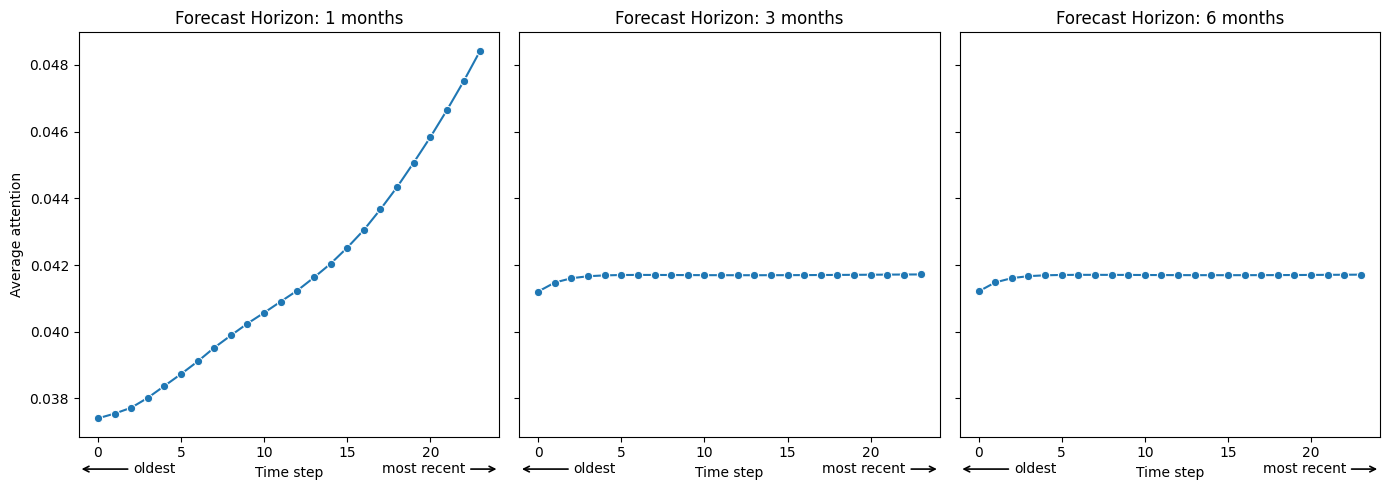

In [28]:
# Attention over the test set
fig, axes = plt.subplots(1, len(fh_grid), figsize=(14, 5), sharey = True)
for i, (ax, fh) in enumerate(zip(axes, fh_grid)):
    mean_attn = attention_results[i].mean(axis = 0)
    sns.lineplot(x=np.arange(len(mean_attn)), y=mean_attn, marker='o', ax = ax)

    ax.set_title(f'Forecast Horizon: {fh} months')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Average attention')
    ax.annotate(
        'oldest',
        xy=(0.00, -0.08),
        xytext=(0.18, -0.08),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        arrowprops=dict(arrowstyle='->', lw=1.2)
    )
    ax.annotate(
        'most recent',
        xy=(1.00, -0.08),
        xytext=(0.82, -0.08),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        arrowprops=dict(arrowstyle='->', lw=1.2)
    )
plt.tight_layout()
plt.savefig('../output/attention_results.png', dpi = 300)
plt.show()

# Covid
Here we restrict our test set to just before covid and during covid. We compute metrics for both different test sets, where the only difference are a few observations with huge outliers

In [29]:
pre_covid = data.loc[data['observation_date'] < "2020-02-01 00:00:00"][stationary_columns].dropna().reset_index(drop= True)
covid = data.loc[data['observation_date'] < "2020-08-01 00:00:00"][stationary_columns].dropna().reset_index(drop = True)

In [30]:
pre_covid_test = MacroVariablesDataset(pre_covid, dl_setup.scaler_x, dl_setup.scaler_y, 1, 24, initial_cut, train= False)
covid_test = MacroVariablesDataset(covid, dl_setup.scaler_x, dl_setup.scaler_y, 1, 24, initial_cut, train= False)

In [31]:
dl_hyp = joblib.load(f"../output/best_dl_hp_1.pkl")['best_params']
dl_model = LSTMForecasting(input_cols= train_dl.features, target_cols= train_dl.targets, hidden_size= dl_hyp['hidden_size'], 
                        num_layers= dl_hyp['num_layers'], p_dropout= dl_hyp['p_dropout'], bidirectional= dl_hyp['bidirectional'])
dl_model, _, _ = train_model(dl_model, train_dl, device, batch_size= 64, num_epochs= dl_hyp['early_stop'], 
                                        lr= dl_hyp['lr'], l2 = dl_hyp['l2'], qui = True, seed= 42)


In [32]:
dl_mse, dl_mae, dl_rmse, dl_true, dl_pred, attn = evaluate_model(dl_model, pre_covid_test, device, batch_size= 64, verbose= True)

MSE:   7.501
MAE:   1.589
RMSE:  1.842


In [33]:
dl_mse, dl_mae, dl_rmse, dl_true, dl_pred, attn = evaluate_model(dl_model, covid_test, device, batch_size= 64, verbose= True)

MSE:   307.413
MAE:   4.503
RMSE:  8.660


We can see that just a few observations with big outliers make a huge difference in our evaluation metrics